In [1]:
import sys 
sys.path.insert(
    0,
    "/raid0/homes/jkitzmann/dev/ITK-build-binarythinning/Wrapping/Generators/Python"
)
import itk

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Typesystem Boilerplate and Helper Functions

In [3]:
PixelType = itk.UC
Dimension = 3
ImageType = itk.Image[PixelType, Dimension]
LabelPixelType = itk.SS
LabelImageType = itk.Image[LabelPixelType, Dimension]
TubeType = itk.TubeSpatialObject[Dimension]
TubePointType = itk.TubeSpatialObjectPoint[Dimension]
PointSetType = itk.PointSet[itk.D, Dimension]

In [4]:
PixelType = itk.UC
Dimension = 3
ImageType = itk.Image[PixelType, Dimension]
FloatImageType = itk.Image[itk.F, Dimension]

def _to_xyz_list(points):
    """Normalize show_points into a list of (x, y, z) tuples.

    Accepts a single ITK index (or (x, y, z) sequence), or a list of them.
    """
    if points is None:
        return []

    # a bare (x, y, z) is one point; a list/tuple of those is many
    if not (isinstance(points, (list, tuple)) and not np.isscalar(points[0])):
        points = [points]

    return [(int(p[0]), int(p[1]), int(p[2])) for p in points]

def show_mip(image, show_points=None, cmap="gray"):
    ar = itk.array_view_from_image(image)

    points = _to_xyz_list(show_points)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(np.max(ar, axis=0), cmap=cmap)
    axes[0].set_title("Axial MIP")
    axes[0].axis("off")

    axes[1].imshow(np.max(ar, axis=1), cmap=cmap)
    axes[1].set_title("Coronal MIP")
    axes[1].axis("off")

    axes[2].imshow(np.max(ar, axis=2), cmap=cmap)
    axes[2].set_title("Sagittal MIP")
    axes[2].axis("off")

    # add points from list
    for ax, (col, row) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
        ax.autoscale(False)
        for point in points:
            ax.scatter(
                point[col],
                point[row],
                s=80,
                facecolors="none",
                edgecolors="red",
                linewidths=1.5,
            )

    plt.tight_layout()
    plt.show()

## Synthetic Airway

In [5]:
import numpy as np
import itk


class SyntheticTube:
    def __init__(self, size=(128, 128, 128)):
        self.size = size
        self.mask = np.zeros(size, dtype=np.uint8)
        self.grid = np.indices(size).transpose(1, 2, 3, 0)
        self.branches = []
        self.pruned = []

    @staticmethod
    def normalize(v):
        return v / np.linalg.norm(v)

    @staticmethod
    def rotate(v, axis, angle):
        axis = SyntheticTube.normalize(axis)
        return (
            v * np.cos(angle)
            + np.cross(axis, v) * np.sin(angle)
            + axis * np.dot(axis, v) * (1 - np.cos(angle))
        )

    @staticmethod
    def point_segment_distance(p, a, b):
        d = b - a
        n = np.dot(d, d)

        if n == 0:
            return np.linalg.norm(p - a)

        t = np.clip(np.dot(p - a, d) / n, 0, 1)
        return np.linalg.norm(p - (a + t * d))

    def add_tube(
        self,
        centerline,
        radius,
        generation,
        branch_id,
        parent_id,
    ):
        centerline = np.asarray(centerline, float)

        for p0, p1 in zip(centerline[:-1], centerline[1:]):
            d = p1 - p0
            n = np.dot(d, d)

            if n == 0:
                continue

            lo = np.clip(
                np.floor(np.minimum(p0, p1) - radius).astype(int),
                0,
                self.size,
            )

            hi = np.clip(
                np.ceil(np.maximum(p0, p1) + radius).astype(int) + 1,
                0,
                self.size,
            )

            if np.any(hi <= lo):
                continue

            region = tuple(slice(a, b) for a, b in zip(lo, hi))
            points = self.grid[region]

            t = np.clip(
                np.sum((points - p0) * d, axis=-1) / n,
                0,
                1,
            )

            distance = np.linalg.norm(
                points - (p0 + t[..., None] * d),
                axis=-1,
            )

            self.mask[region][distance <= radius] = 1

        self.branches.append({
            "branch_id": branch_id,
            "parent_id": parent_id,
            "generation": generation,
            "centerline": centerline,
            "radius": radius,
            "length": np.linalg.norm(
                np.diff(centerline, axis=0),
                axis=1,
            ).sum(),
        })

    def clear_length(
        self,
        origin,
        direction,
        radius,
        length,
        ignore,
        min_gap,
        step=0.25,
    ):
        for s in np.arange(0, length + step, step):
            s = min(s, length)
            p = origin + s * direction

            for branch in self.branches:
                if branch["branch_id"] in ignore:
                    continue

                clearance = radius + branch["radius"] + min_gap
                c = branch["centerline"]

                if any(
                    self.point_segment_distance(p, a, b) < clearance
                    for a, b in zip(c[:-1], c[1:])
                ):
                    return max(0, s - step)

        return length

    def grow(
        self,
        centerline,
        radius,
        generation,
        branch_id,
        parent_id,
        max_generations,
        branch_length,
        radius_scale,
        length_scale,
        angle,
        normal,
        min_gap,
        min_length_fraction,
        pruned_length_scale,
    ):
        self.add_tube(
            centerline,
            radius,
            generation,
            branch_id,
            parent_id,
        )

        if generation >= max_generations - 1:
            return

        direction = self.normalize(
            centerline[-1] - centerline[-2]
        )

        origin = centerline[-1]

        directions = [
            self.normalize(self.rotate(direction, normal, angle)),
            self.normalize(self.rotate(direction, normal, -angle)),
        ]

        child_radius = radius * radius_scale
        child_length = branch_length * length_scale
        child_ids = (2 * branch_id + 1, 2 * branch_id + 2)

        for child_id, child_direction in zip(child_ids, directions):

            # Give the candidate branch extra room to extend before
            # deciding whether it is pruned.
            requested_length = child_length * pruned_length_scale

            length = self.clear_length(
                origin,
                child_direction,
                child_radius,
                requested_length,
                {branch_id, *child_ids},
                min_gap,
            )

            if length < min_length_fraction * child_length:
                self.pruned.append(child_id)
                continue

            child = np.array([
                origin,
                origin + child_direction * length / 2,
                origin + child_direction * length,
            ])

            self.grow(
                child,
                child_radius,
                generation + 1,
                child_id,
                branch_id,
                max_generations,
                child_length,
                radius_scale,
                length_scale,
                angle,
                normal,
                min_gap,
                min_length_fraction,
                pruned_length_scale,
            )

    def make_tree(
        self,
        centerline,
        radius=6,
        generations=5,
        branch_length=15,
        radius_scale=0.75,
        length_scale=0.75,
        bifurcation_angle=45,
        plane_normal=(1, 0, 0),
        min_gap=1,
        min_length_fraction=0.5,
        pruned_length_scale=1.5,
    ):
        centerline = np.asarray(centerline, float)

        direction = self.normalize(
            centerline[-1] - centerline[-2]
        )

        normal = np.asarray(plane_normal, float)
        normal -= np.dot(normal, direction) * direction

        if np.linalg.norm(normal) < 1e-6:
            raise ValueError(
                "plane_normal is parallel to root direction"
            )

        self.grow(
            centerline,
            radius,
            0,
            0,
            None,
            generations,
            branch_length,
            radius_scale,
            length_scale,
            np.deg2rad(bifurcation_angle),
            self.normalize(normal),
            min_gap,
            min_length_fraction,
            pruned_length_scale,
        )

        return self

    def to_numpy(self):
        return self.mask

    def to_itk(self):
        return itk.image_from_array(self.mask)

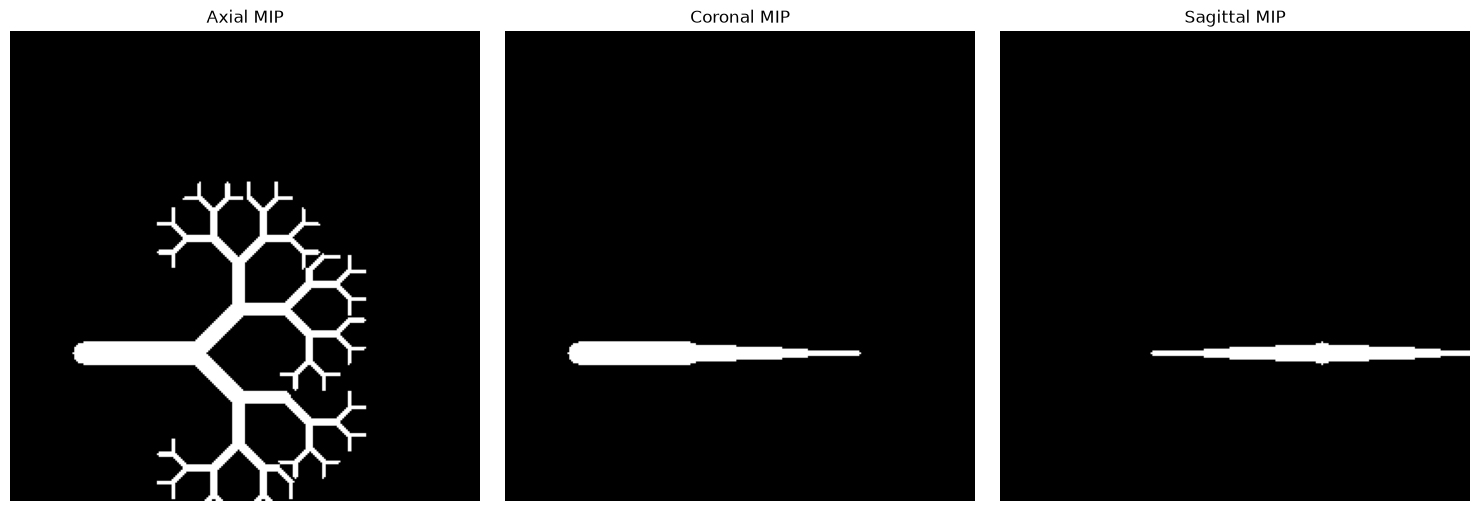

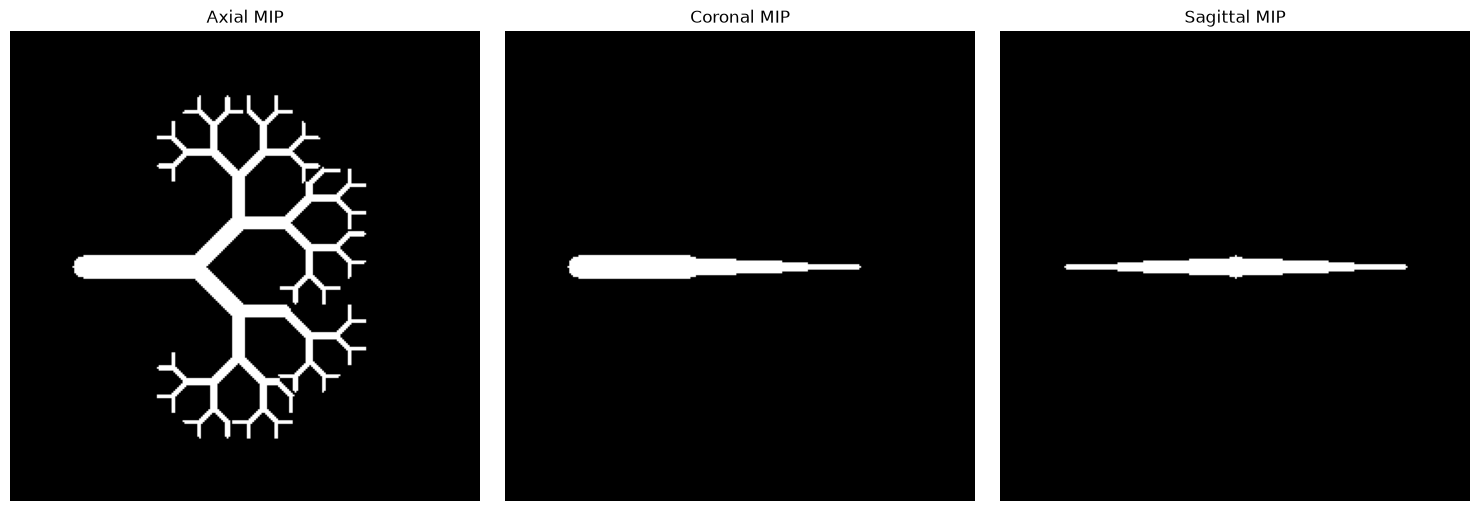

In [6]:
fixed_airway = SyntheticTube(
    size=(256, 256, 256)
)
fixed_airway.make_tree(
    centerline=[
        (128, 128, 40),
        (128, 128, 70),
        (128, 128, 100),
    ],
    radius=6,
    generations=7,
    branch_length=30,
    bifurcation_angle=45.0,
    plane_normal=(1.0, 0.0, 0.0),
)

moving_airway = SyntheticTube(
    size=(256, 256, 256)
)
moving_airway.make_tree(
    centerline=[
        (175, 175, 40),
        (175, 175, 70),
        (175, 175, 100),
    ],
    radius=6,
    generations=7,
    branch_length=30,
    bifurcation_angle=45.0,
    plane_normal=(1.0, 0.0, 0.0),
)

moving_image = moving_airway.to_itk()
fixed_image = fixed_airway.to_itk()

show_mip(moving_image)
show_mip(fixed_image)


## Deformable Registration and Analysis Pipeline

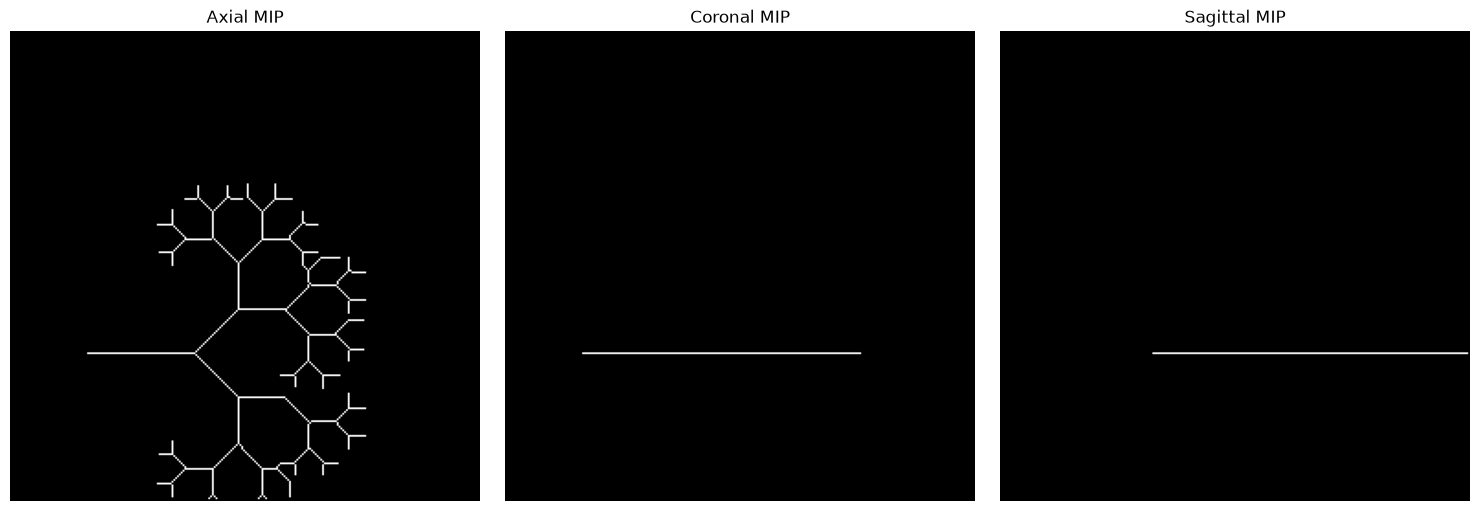

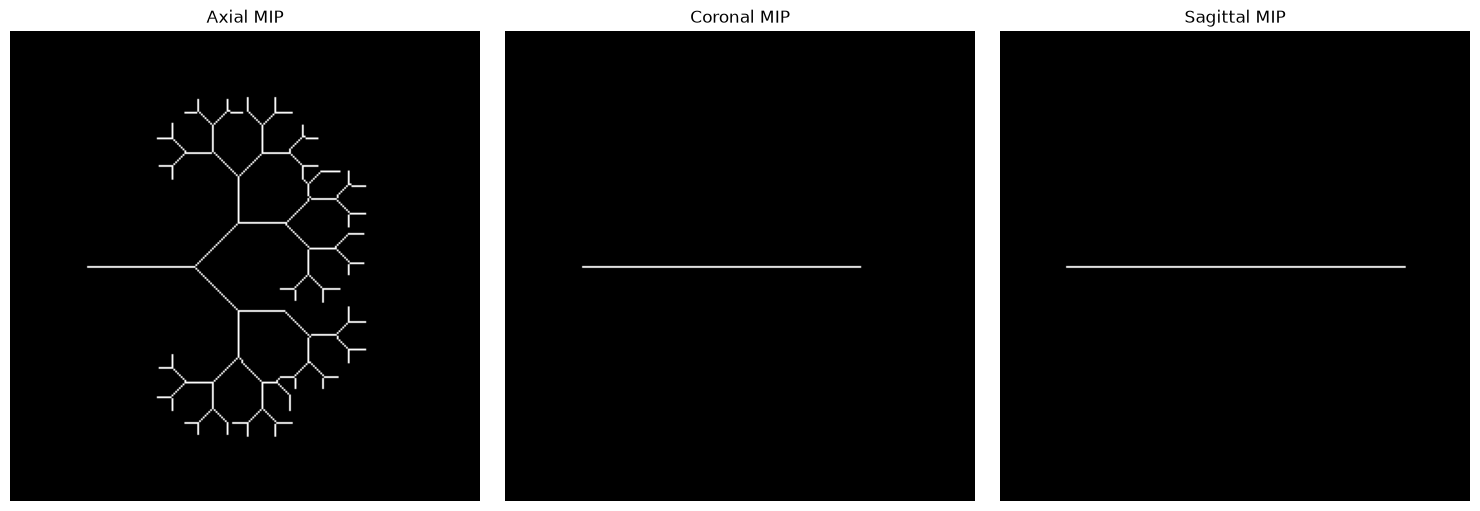

In [7]:
SkeletonizeAirwayType = itk.SkeletonizeAirway[ImageType]

skeletonizeAirwayPrediction = SkeletonizeAirwayType.New()
skeletonizeAirwayPrediction.SetInput(moving_image)
skeletonizeAirwayPrediction.Update()
moving_skeleton = skeletonizeAirwayPrediction.GetOutput()
show_mip(moving_skeleton)

skeletonizeAirwayGroundTruth = SkeletonizeAirwayType.New()
skeletonizeAirwayGroundTruth.SetInput(fixed_image)
skeletonizeAirwayGroundTruth.Update()
fixed_skeleton = skeletonizeAirwayGroundTruth.GetOutput()
show_mip(fixed_skeleton)

## Initial Labeling

widest index: [43, 175, 175]


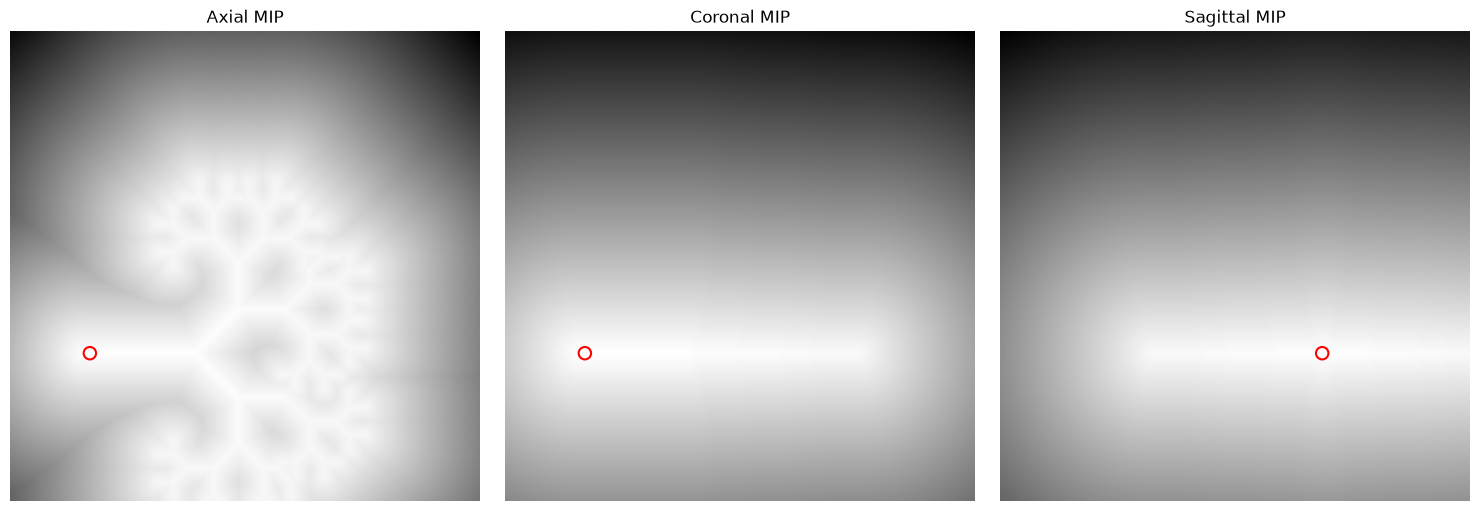

widest index: [43, 128, 128]


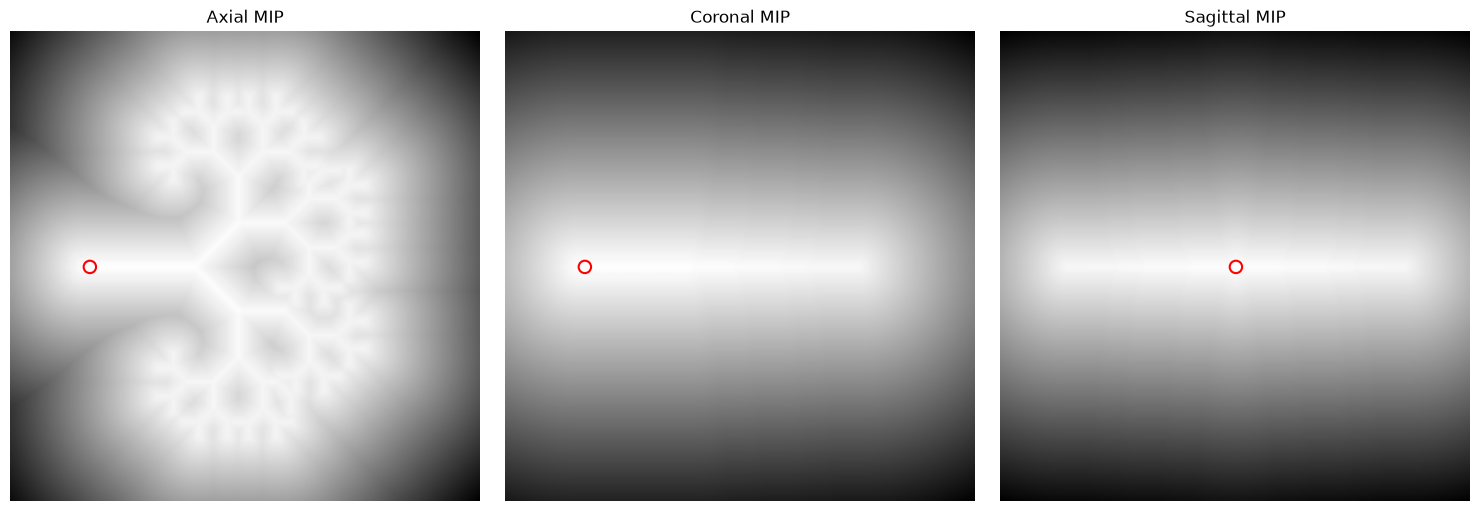

In [8]:
LabelPixelType = itk.SS
LabelImageType = itk.Image[LabelPixelType, Dimension]

SkeletonLabelingType = itk.SkeletonLabeling[ImageType, LabelImageType]

skeletonLabelingPrediction = SkeletonLabelingType.New()
skeletonLabelingPrediction.SetMaskImage(moving_image)
skeletonLabelingPrediction.SetSkeletonImage(moving_skeleton)
skeletonLabelingPrediction.SetMinimumLandmarkDistance(5.0)
skeletonLabelingPrediction.SetSensitivityMultiplier(1.0)
skeletonLabelingPrediction.Update()
branchLabelsImagePrediction = skeletonLabelingPrediction.GetBranchLabelsImage()
generationLabelsImagePrediction = skeletonLabelingPrediction.GetGenerationLabelsImage()
distanceMapImagePrediction = skeletonLabelingPrediction.GetDistanceMapImage()
widestIndexPrediction = skeletonLabelingPrediction.GetWidestIndex()

print("widest index:", list(widestIndexPrediction))
show_mip(distanceMapImagePrediction, show_points=widestIndexPrediction)

skeletonLabelingGroundTruth = SkeletonLabelingType.New()
skeletonLabelingGroundTruth.SetMaskImage(fixed_image)
skeletonLabelingGroundTruth.SetSkeletonImage(fixed_skeleton)
skeletonLabelingGroundTruth.SetSensitivityMultiplier(1.0)
skeletonLabelingGroundTruth.SetMinimumLandmarkDistance(5.0)
skeletonLabelingGroundTruth.Update()
branchLabelsImageGroundTruth = skeletonLabelingGroundTruth.GetBranchLabelsImage()
generationLabelsImageGroundTruth = skeletonLabelingGroundTruth.GetGenerationLabelsImage()
distanceMapImageGroundTruth = skeletonLabelingGroundTruth.GetDistanceMapImage()
widestIndexGroundTruth = skeletonLabelingGroundTruth.GetWidestIndex()

print("widest index:", list(widestIndexGroundTruth))
show_mip(distanceMapImageGroundTruth, show_points=widestIndexGroundTruth)

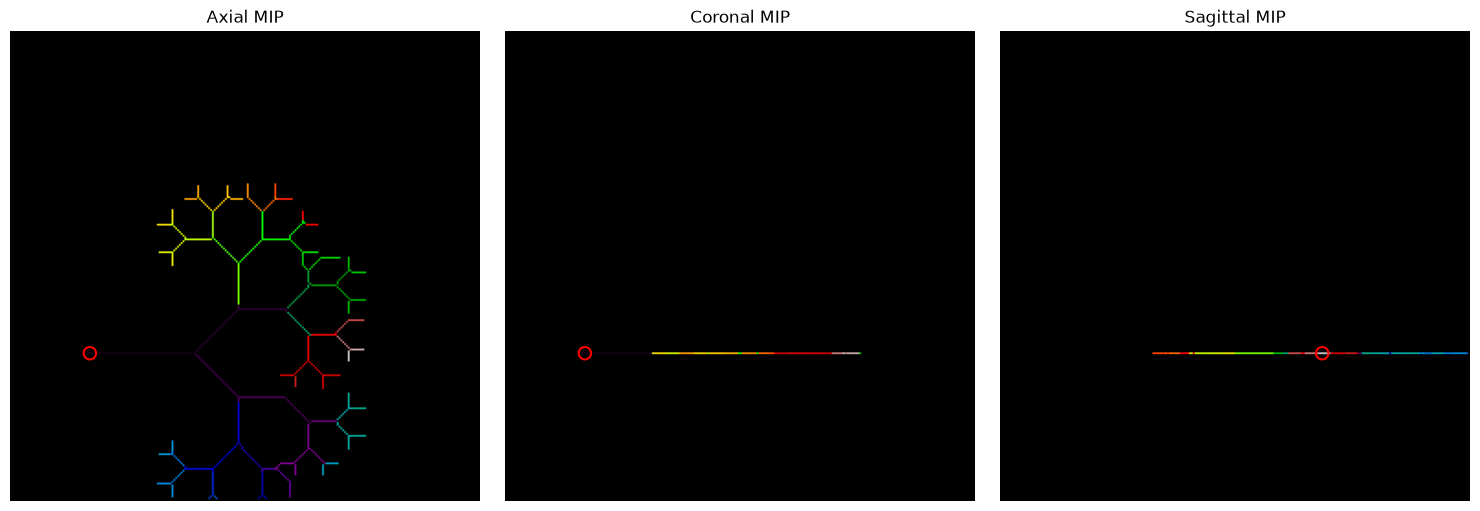

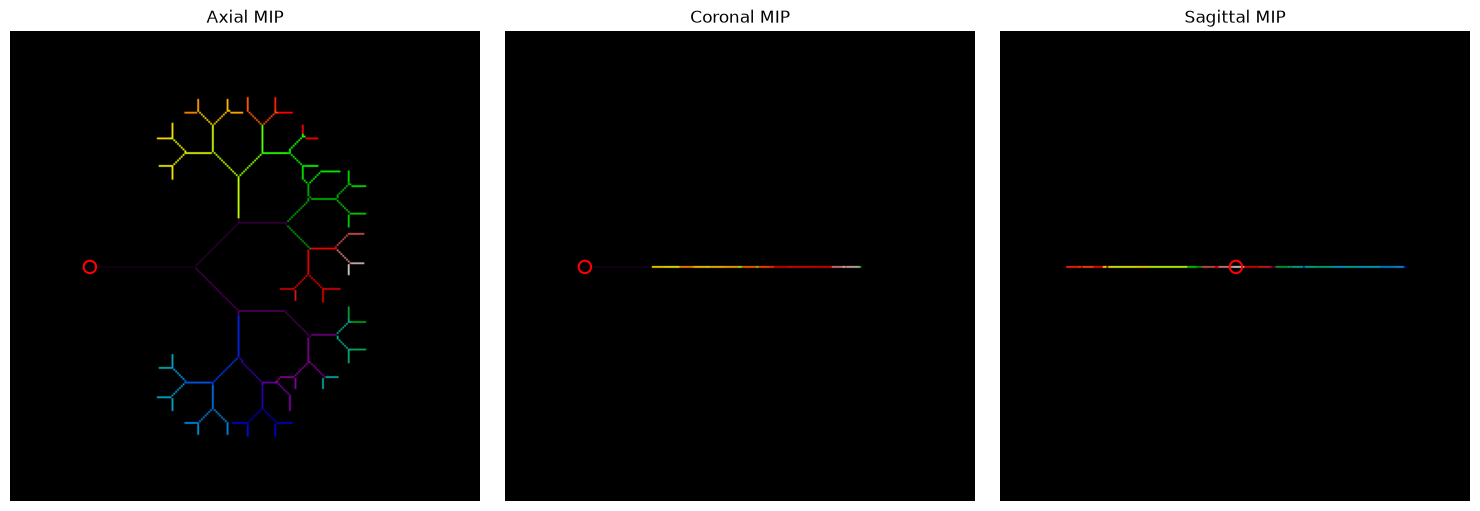

In [9]:
branch_labels_prediction = itk.array_view_from_image(branchLabelsImagePrediction)
show_mip(branchLabelsImagePrediction, show_points=widestIndexPrediction, cmap="nipy_spectral")

branch_labels_groundTruth = itk.array_view_from_image(branchLabelsImageGroundTruth)
show_mip(branchLabelsImageGroundTruth, show_points=widestIndexGroundTruth, cmap="nipy_spectral")


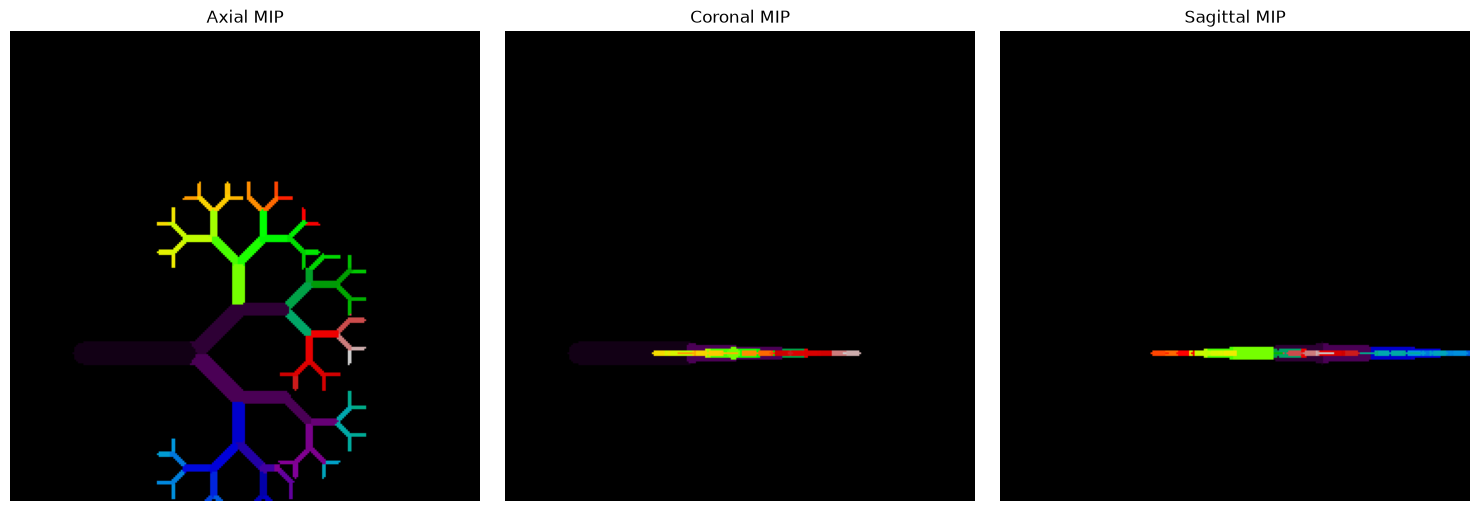

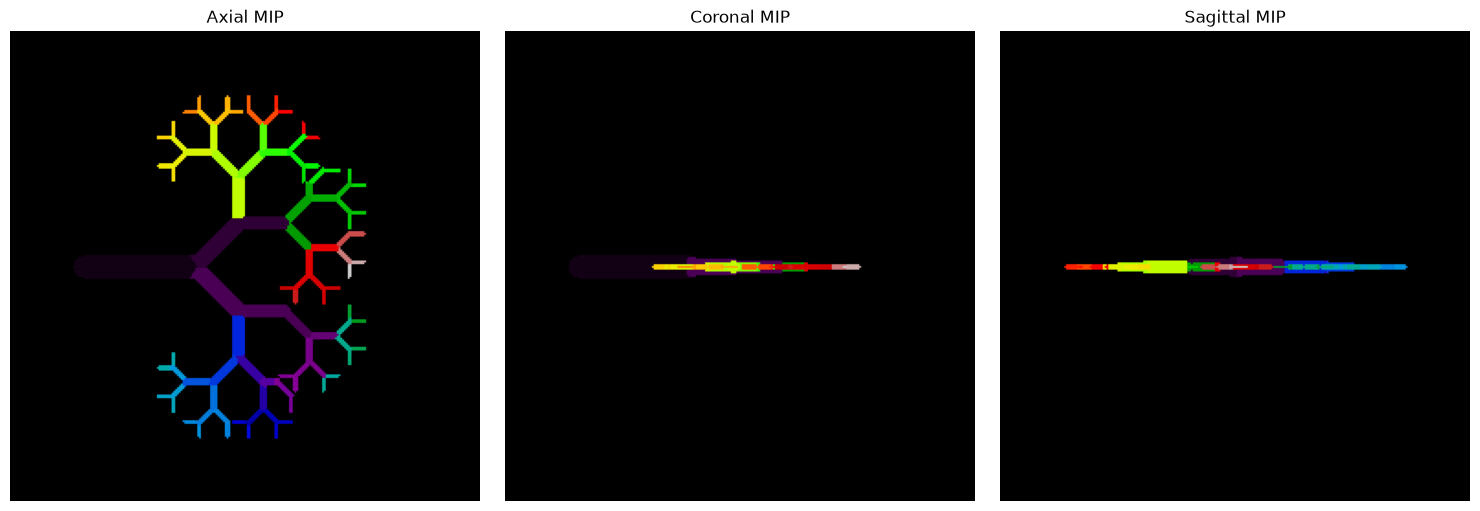

In [10]:
ProjectAirwayType = itk.ProjectAirway[ImageType, LabelImageType]

projectAirwayPrediction = ProjectAirwayType.New()
projectAirwayPrediction.SetSegmentationImage(moving_image)
projectAirwayPrediction.SetBranchSkeletonLabelsImage(branchLabelsImagePrediction)
projectAirwayPrediction.SetGenerationSkeletonLabelsImage(generationLabelsImagePrediction)
projectAirwayPrediction.SetNumberOfNeighbors(5)
projectAirwayPrediction.Update()
projectedBranchLabelsImagePrediction = projectAirwayPrediction.GetBranchLabelsImage()
show_mip(projectedBranchLabelsImagePrediction, cmap="nipy_spectral")

projectAirwayGroundTruth = ProjectAirwayType.New()
projectAirwayGroundTruth.SetSegmentationImage(fixed_image)
projectAirwayGroundTruth.SetBranchSkeletonLabelsImage(branchLabelsImageGroundTruth)
projectAirwayGroundTruth.SetGenerationSkeletonLabelsImage(generationLabelsImageGroundTruth)
projectAirwayGroundTruth.SetNumberOfNeighbors(5)
projectAirwayGroundTruth.Update()
projectedBranchLabelsImageGroundTruth = projectAirwayGroundTruth.GetBranchLabelsImage()
show_mip(projectedBranchLabelsImageGroundTruth, cmap="nipy_spectral")

moving_image = projectedBranchLabelsImagePrediction
fixed_image = projectedBranchLabelsImageGroundTruth

## Get Branch Points

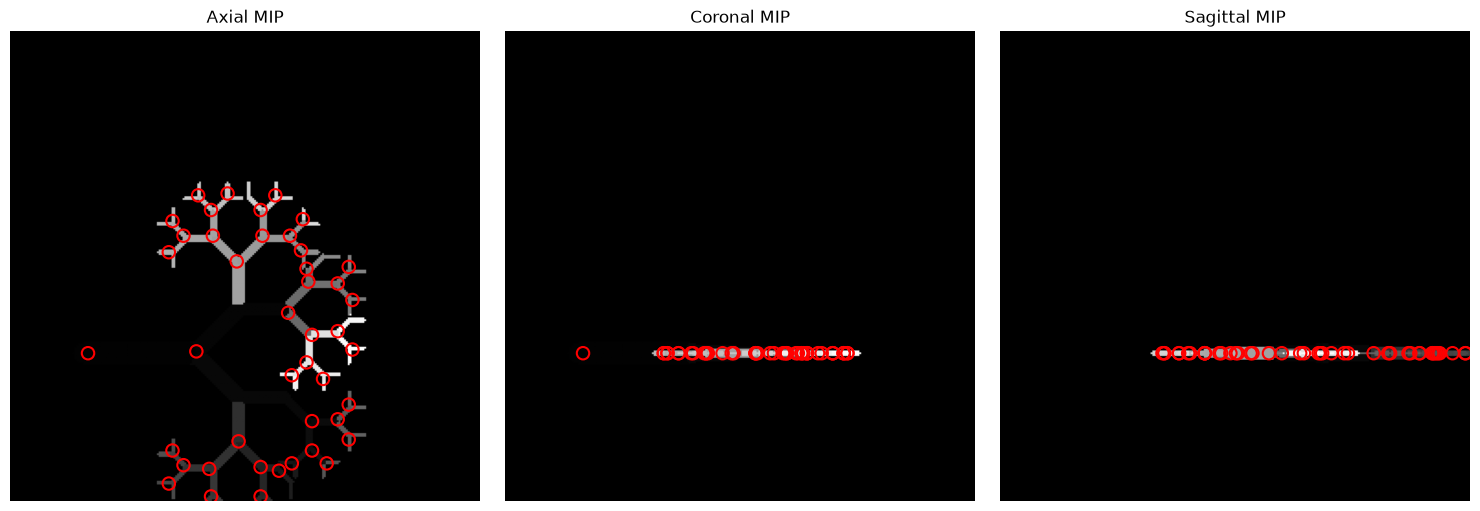

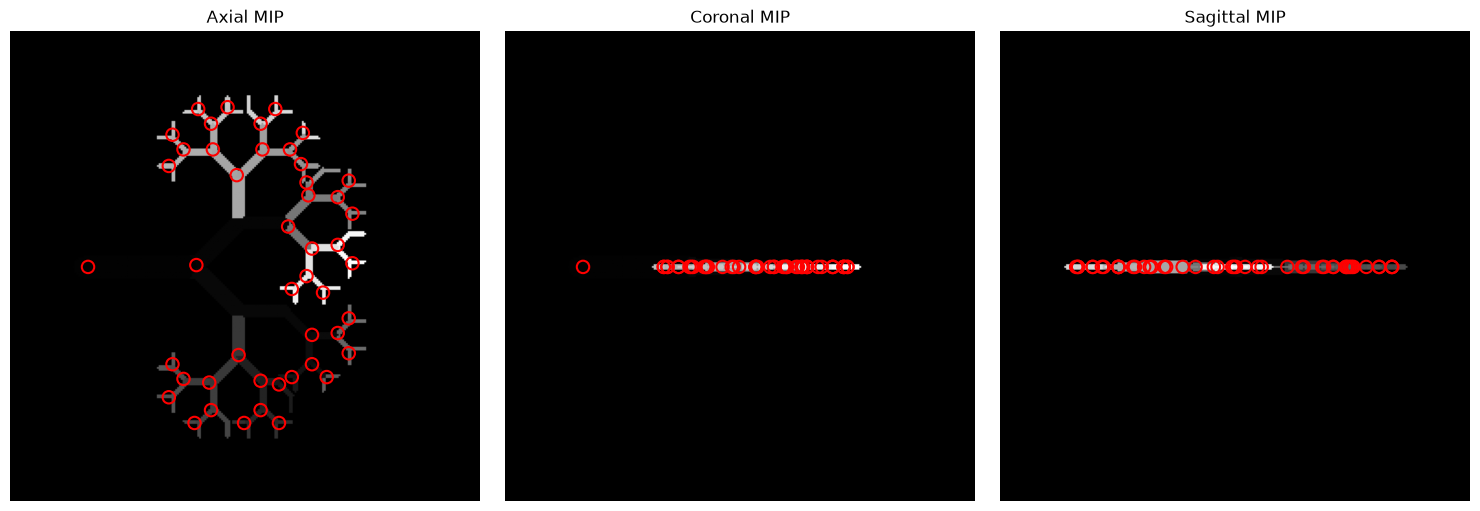

In [11]:
branch_ids_prediction = skeletonLabelingPrediction.GetLandmarks()
branch_origins_prediction = [
    skeletonLabelingPrediction.GetBranchOriginIndex(i)
    for i in branch_ids_prediction
]

branch_ids_groundTruth = skeletonLabelingGroundTruth.GetLandmarks()
branch_origins_groundTruth = [
    skeletonLabelingGroundTruth.GetBranchOriginIndex(i)
    for i in branch_ids_groundTruth
]

show_mip(moving_image, branch_origins_prediction)
show_mip(fixed_image, branch_origins_groundTruth)

In [12]:
def convert_points(point_list):
    point_set = PointSetType.New()
    point_set_points = point_set.GetPoints()
    for idx, point in enumerate(point_list):
        point_output = itk.Point[itk.D, Dimension]()
        point_output[0] = point[0]
        point_output[1] = point[1]
        point_output[2] = point[2]
        
        point_set_points.InsertElement(idx, point_output)

    return point_set

fixed_points = convert_points(branch_origins_groundTruth)
moving_points = convert_points(branch_origins_prediction)

fixed_points

<itk.itkPointSetPython.itkPointSetD3; proxy of <Swig Object of type 'itkPointSetD3 *' at 0x7ff460529930> >

In [13]:
## Rigid alignment for point matching

In [14]:
RigidlyAlignAirwaysType = itk.RigidlyAlignAirways[PointSetType]
rigidlyAlignAirways = RigidlyAlignAirwaysType.New()
rigidlyAlignAirways.SetFixedPointSet(fixed_points)
rigidlyAlignAirways.SetMovingPointSet(moving_points)
rigidlyAlignAirways.Update()
transform = rigidlyAlignAirways.GetTransform()
print(transform.GetMatrix())

itkMatrixD33 ([[0.9999999997042313, -6.025101482613092e-06, -2.3563439584287104e-05], [6.025191480516762e-06, 0.9999999999745549, 3.81931825330744e-06], [2.3563416571907457e-05, -3.81946022641324e-06, 0.9999999997150886]])Stop condition: LevenbergMarquardtOptimizer: Levenberg-Marquardt converged



In [15]:
aligned = itk.resample_image_filter(
    moving_airway.to_itk(),
    transform=transform.GetInverseTransform(),
    use_reference_image=True,
    reference_image=fixed_image,
    interpolator = itk.NearestNeighborInterpolateImageFunction.New(moving_airway.to_itk()),
    default_pixel_value=0
)

In [16]:
transform = rigidlyAlignAirways.GetTransform()
aligned_points_list = []

for i in range(moving_points.GetNumberOfPoints()):
    point = moving_points.GetPoint(i)
    aligned_point = transform.TransformPoint(point)
    aligned_points_list.append(aligned_point)

aligned_points = convert_points(aligned_points_list)

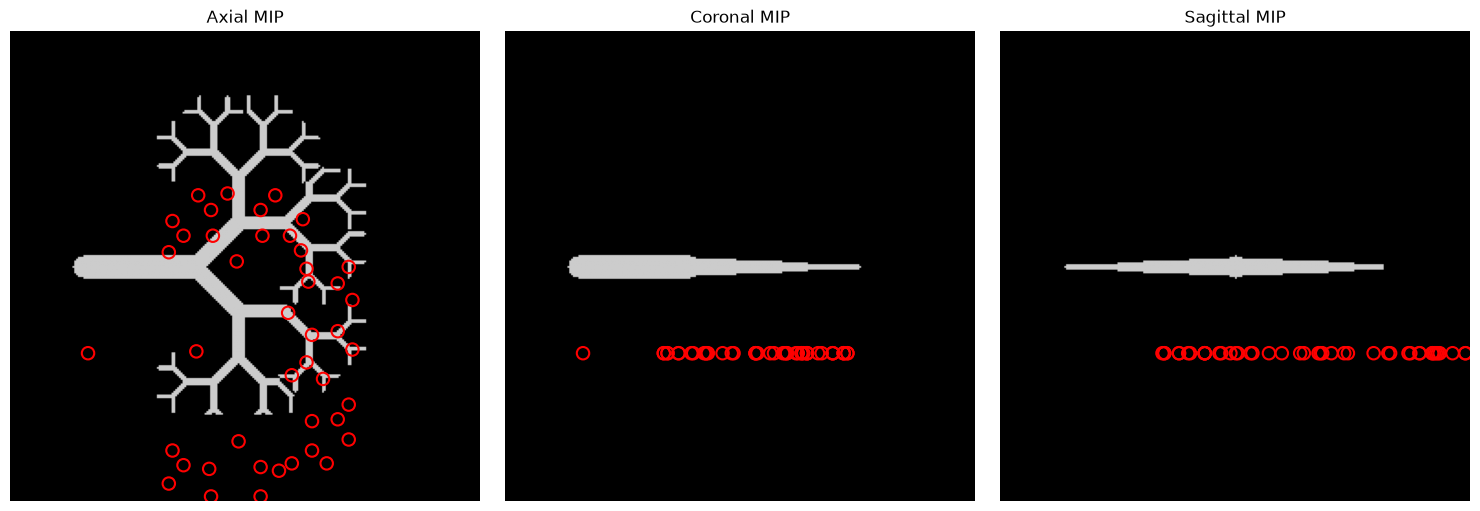

<class 'itk.itkPointSetPython.itkPointSetD3'>


In [17]:
show_mip(aligned, show_points=branch_origins_prediction, cmap='nipy_spectral')
print(type(aligned_points))

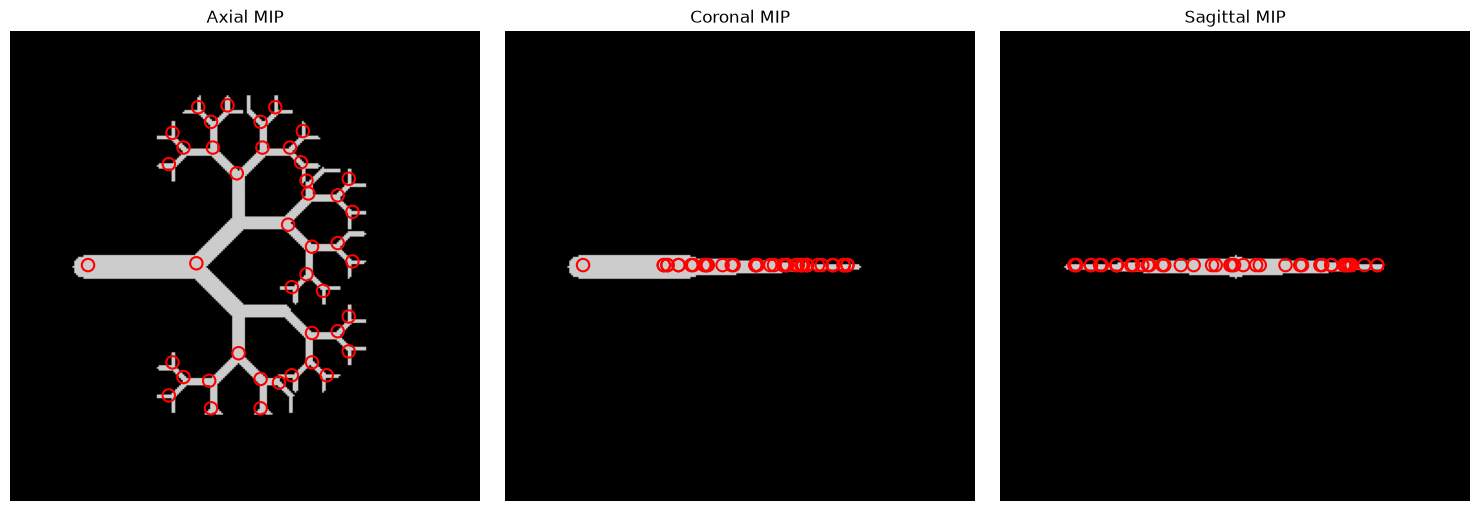

<class 'itk.itkPointSetPython.itkPointSetD3'>


In [18]:
show_mip(aligned, show_points=aligned_points_list, cmap='nipy_spectral')
print(type(aligned_points))

## Skeletonized Resampled

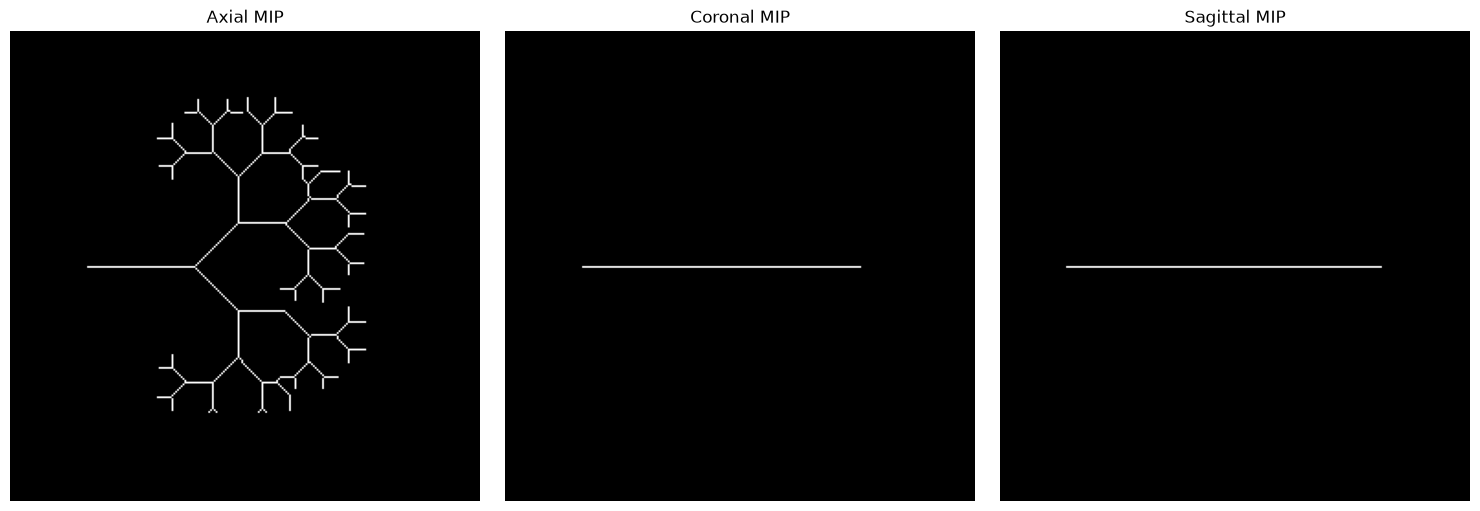

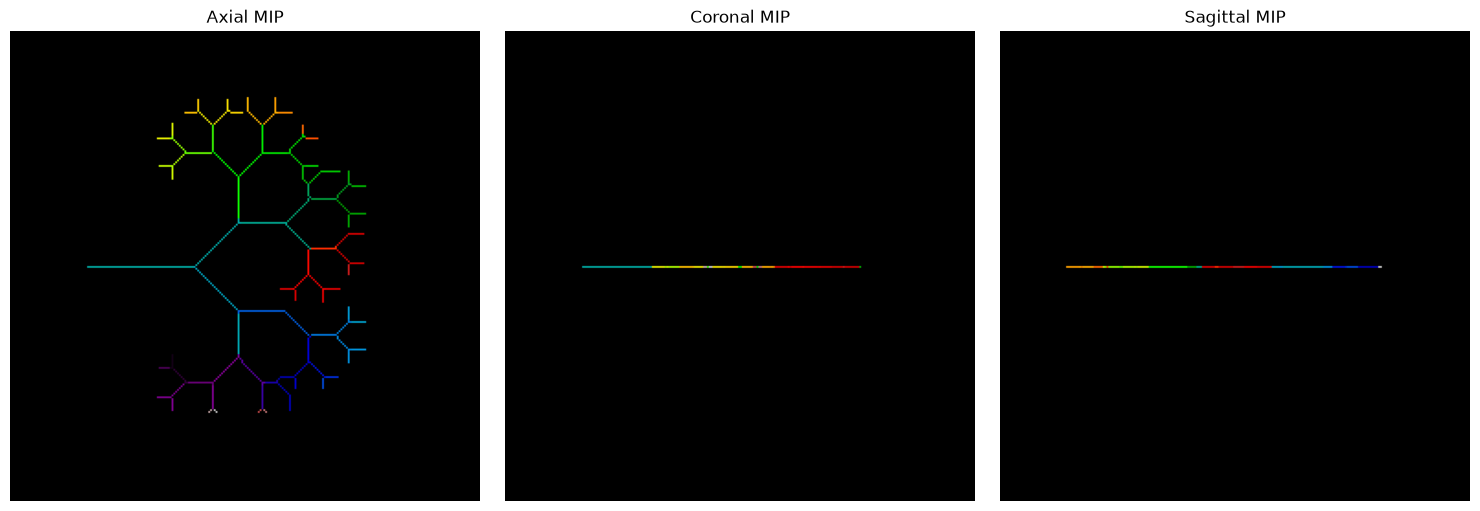

In [19]:
skeletonizeAirwayAligned = SkeletonizeAirwayType.New()
skeletonizeAirwayAligned.SetInput(aligned)
skeletonizeAirwayAligned.Update()
aligned_skeleton = skeletonizeAirwayAligned.GetOutput()
show_mip(aligned_skeleton)

skeletonLabelingAligned = SkeletonLabelingType.New()
skeletonLabelingAligned.SetMaskImage(moving_airway.to_itk())
skeletonLabelingAligned.SetSkeletonImage(aligned_skeleton)
skeletonLabelingAligned.SetSensitivityMultiplier(1.0)
skeletonLabelingAligned.Update()
show_mip(skeletonLabelingAligned.GetBranchLabelsImage(), cmap='nipy_spectral')

In [20]:
def terminal_nonterminal(image, labeling_class, is_terminal):
    array = itk.array_from_image(image).copy()

    for index in np.ndindex(array.shape):
        value = array[index]

        if value == 0:
            continue

        if labeling_class.IsBranchTerminal(int(value)) != is_terminal:
            array[index] = 0

    output = itk.image_from_array(array)
    output.CopyInformation(image)

    return output

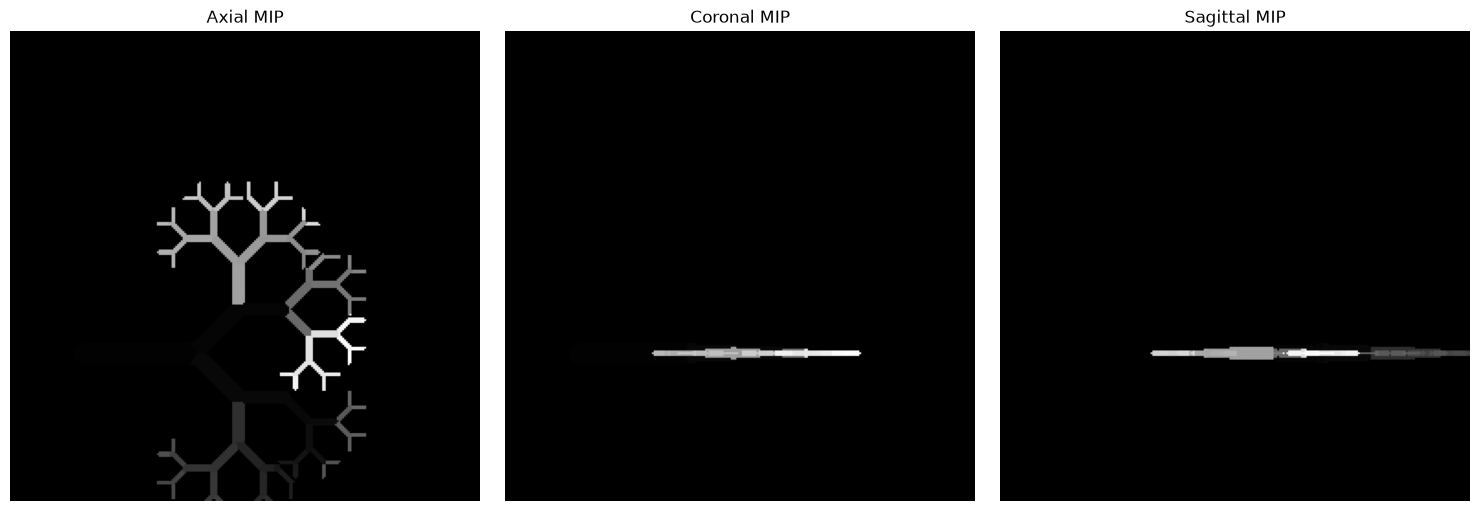

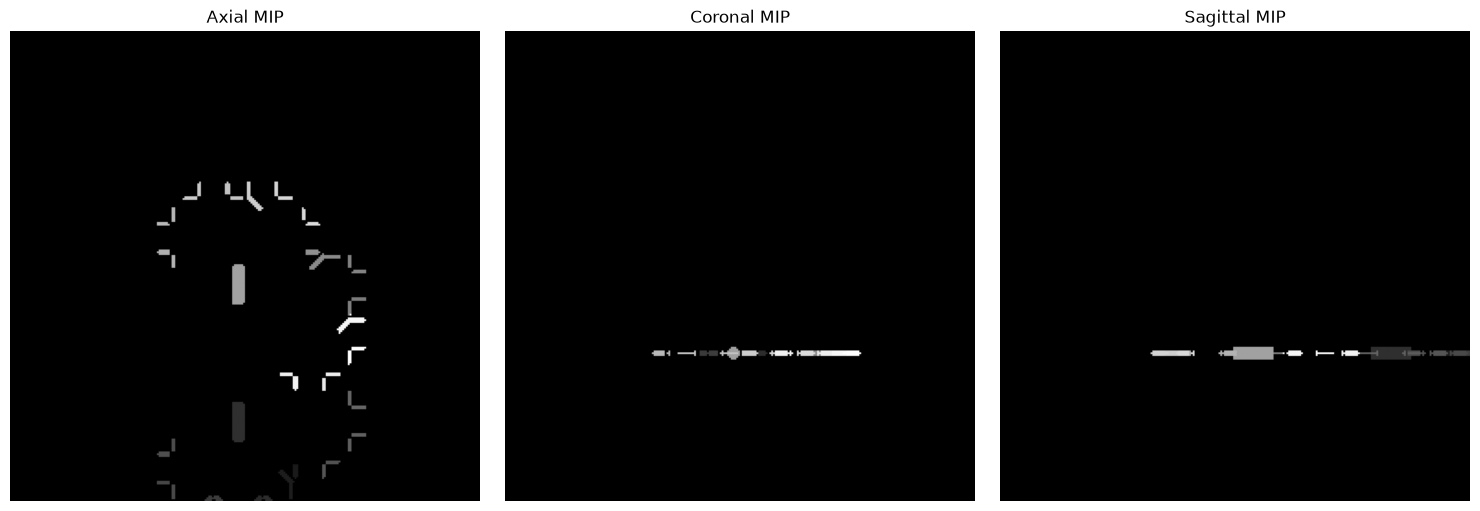

In [ ]:
nonterminal_moving = terminal_nonterminal(projectAirwayPrediction.GetBranchLabelsImage(), skeletonLabelingPrediction, False)
show_mip(moving_image)
terminal_moving = terminal_nonterminal(projectAirwayPrediction.GetBranchLabelsImage(), skeletonLabelingPrediction, True)
show_mip(terminal_moving)

nonterminal_fixed = terminal_nonterminal(projectAirwayGroundTruth.GetBranchLabelsImage(), skeletonLabelingGroundTruth, False)
show_mip(nonterminal_fixed)
terminal_fixed = terminal_nonterminal(projectAirwayGroundTruth.GetBranchLabelsImage(), skeletonLabelingGroundTruth, True)
show_mip(terminal_fixed)


## Branch Point Pairing

In [ ]:
fixed_landmark_ids = skeletonLabelingGroundTruth.GetLandmarks()
moving_landmark_ids = skeletonLabelingPrediction.GetLandmarks()

# -------------------------------------------------------------------------
# Build KD-tree from transformed moving landmarks.
# -------------------------------------------------------------------------

MeasurementVectorType = itk.Vector[itk.F, Dimension]
SampleType = itk.ListSample[MeasurementVectorType]

sample = SampleType.New()
sample.SetMeasurementVectorSize(Dimension)

for moving_id in range(aligned_points.GetNumberOfPoints()):
    point = aligned_points.GetPoint(moving_id)

    measurement = MeasurementVectorType()
    measurement[0] = point[0]
    measurement[1] = point[1]
    measurement[2] = point[2]

    sample.PushBack(measurement)

KdTreeGeneratorType = itk.KdTreeGenerator[SampleType]

generator = KdTreeGeneratorType.New()
generator.SetSample(sample)
generator.SetBucketSize(16)
generator.Update()

kd_tree = generator.GetOutput()

# -------------------------------------------------------------------------
# Find nearest transformed moving landmark for each fixed landmark.
#
# pairs:
#   fixed point index
#   moving point index
#   distance
# -------------------------------------------------------------------------

pairs = []

for fixed_id in range(fixed_points.GetNumberOfPoints()):
    fixed_point = fixed_points.GetPoint(fixed_id)

    query = MeasurementVectorType()
    query[0] = fixed_point[0]
    query[1] = fixed_point[1]
    query[2] = fixed_point[2]

    neighbor_ids = itk.vectorUL()
    neighbor_distances = itk.vectorD()

    kd_tree.Search(
        query,
        1,
        neighbor_ids,
        neighbor_distances
    )

    moving_id = neighbor_ids[0]
    distance = neighbor_distances[0]

    pairs.append(
        (fixed_id, moving_id, distance)
    )

# -------------------------------------------------------------------------
# Convert point indices to branch IDs.
# -------------------------------------------------------------------------

branch_pairs = []

for fixed_id, moving_id, distance in pairs:
    fixed_branch_id = fixed_landmark_ids[fixed_id]
    moving_branch_id = moving_landmark_ids[moving_id]

    branch_pairs.append(
        (fixed_branch_id, moving_branch_id, distance)
    )

# -------------------------------------------------------------------------
# Print branch correspondences.
# -------------------------------------------------------------------------

for fixed_branch_id, moving_branch_id, distance in branch_pairs:
    print(
        "Fixed branch",
        fixed_branch_id,
        "<-> Moving branch",
        moving_branch_id,
        f"({distance:.3f} mm)"
    )

# -------------------------------------------------------------------------
# Reorder transformed moving points into fixed-point order.
# -------------------------------------------------------------------------

PointSetType = type(aligned_points)
reordered_moving = PointSetType.New()

for fixed_id, moving_id, distance in pairs:
    reordered_moving.SetPoint(
        fixed_id,
        aligned_points.GetPoint(moving_id)
    )

## TPS Registration with Nonterminal Images, Should be unaffected by excess terminal landmarks

In [ ]:
thin_plate_spline = itk.ThinPlateSplineKernelTransform[
    itk.D, Dimension
].New()

source = thin_plate_spline.GetSourceLandmarks()
target = thin_plate_spline.GetTargetLandmarks()

for i in range(reordered_moving.GetNumberOfPoints()):
    source.SetPoint(
        i,
        reordered_moving.GetPoint(i)
    )

for i in range(fixed_points.GetNumberOfPoints()):
    target.SetPoint(
        i,
        fixed_points.GetPoint(i)
    )

thin_plate_spline.ComputeWMatrix()

In [ ]:
deformed_nonterminal_moving = itk.resample_image_filter(
    nonterminal_moving, 
    use_reference_image=True, 
    reference_image=nonterminal_fixed, 
    interpolator=itk.NearestNeighborInterpolateImageFunction.New(nonterminal_moving), 
    transform=thin_plate_spline )

In [ ]:
show_mip(deformed_nonterminal_moving)

In [ ]:
show_mip(nonterminal_fixed)

## Terminal Translation and MSE Rotation